Epoch 0, loss 0.2545
Epoch 250, loss 0.2506
Epoch 500, loss 0.2502
Epoch 750, loss 0.2500
Epoch 1000, loss 0.2499
Epoch 1250, loss 0.2497
Epoch 1500, loss 0.2495
Epoch 1750, loss 0.2490
Epoch 2000, loss 0.2480
Epoch 2250, loss 0.2454
Epoch 2500, loss 0.2391
Epoch 2750, loss 0.2260
Epoch 3000, loss 0.2022
Epoch 3250, loss 0.1658
Epoch 3500, loss 0.1198
Epoch 3750, loss 0.0766
Epoch 4000, loss 0.0481
Epoch 4250, loss 0.0320
Epoch 4500, loss 0.0229
Epoch 4750, loss 0.0174


/tmp/ipykernel_1288/2906347016.py:79: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150, edgecolors='k')


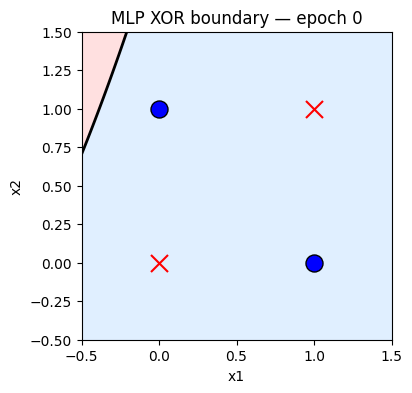

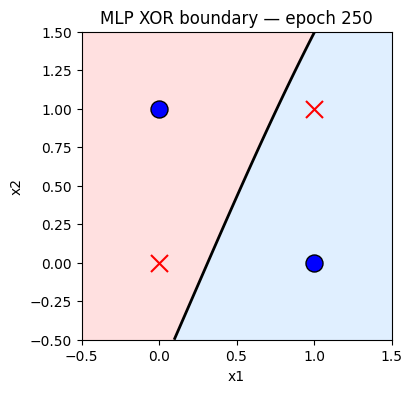

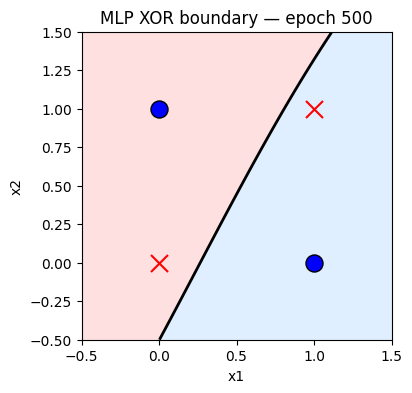

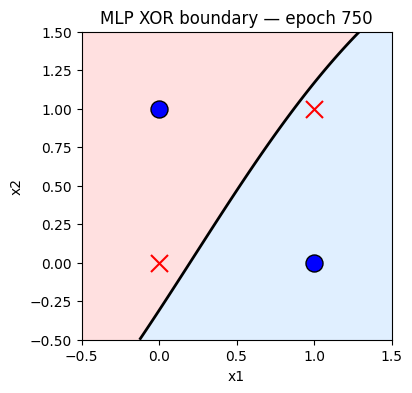

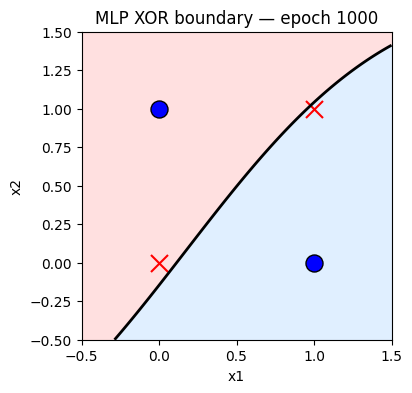

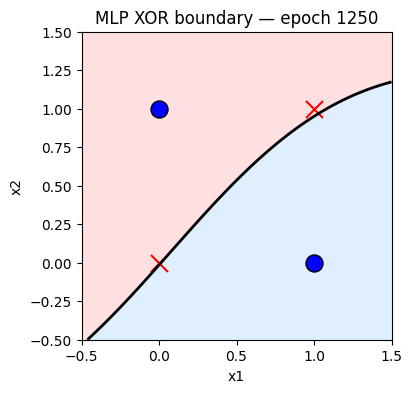

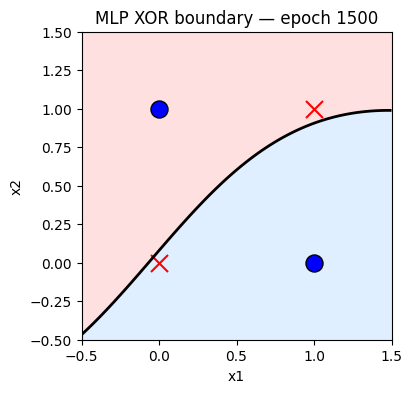

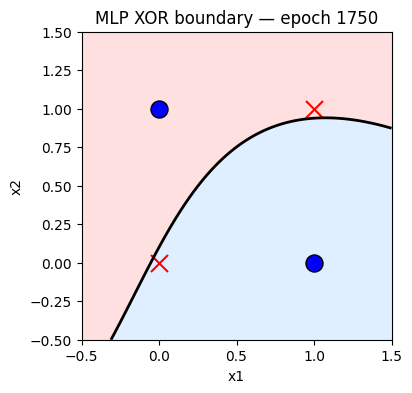

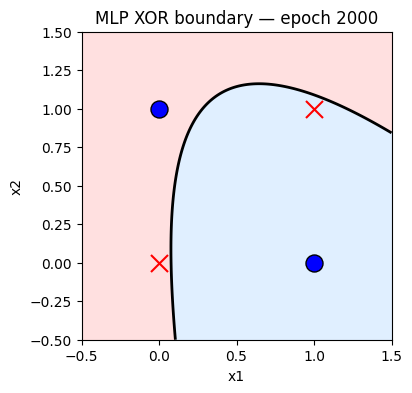

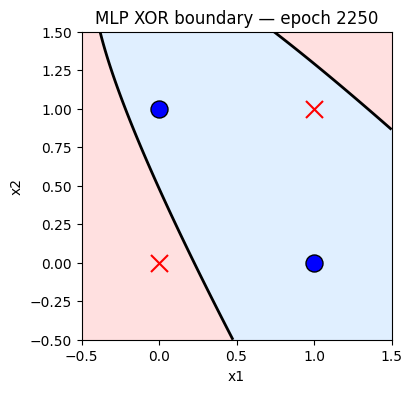

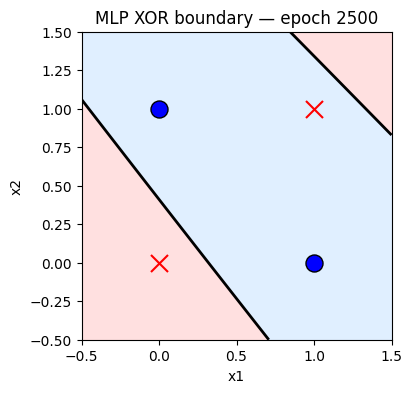

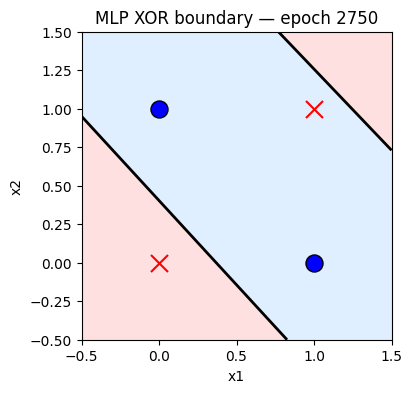

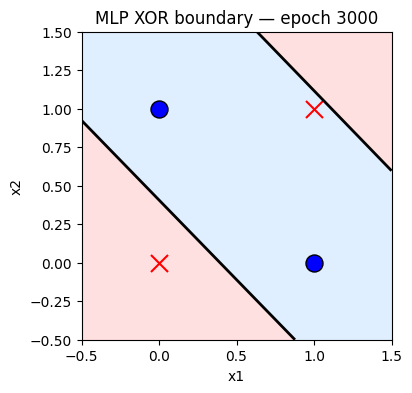

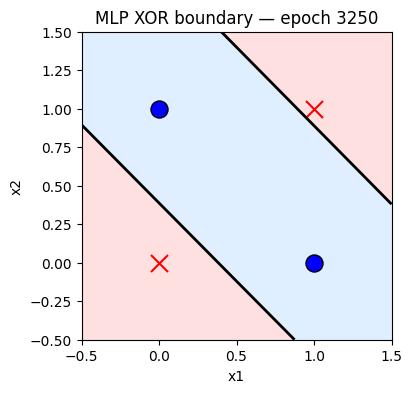

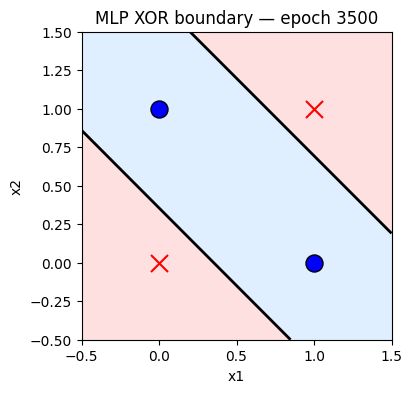

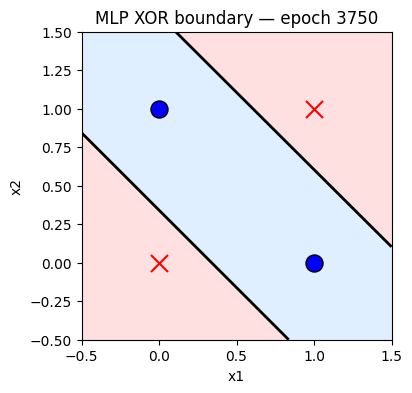

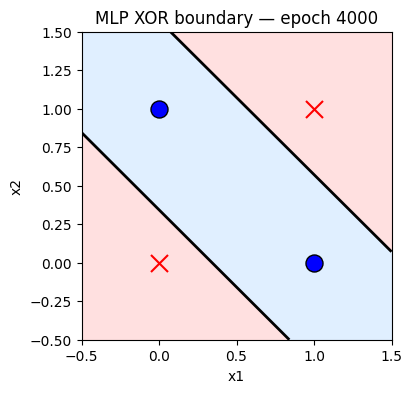

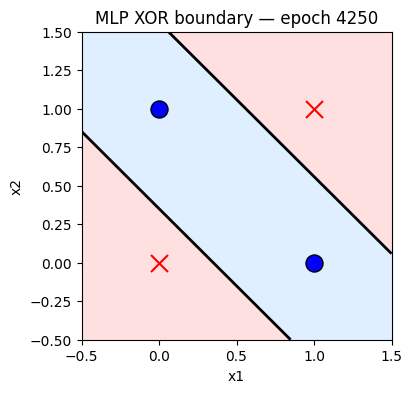

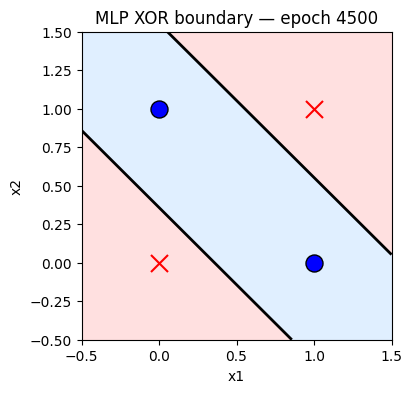

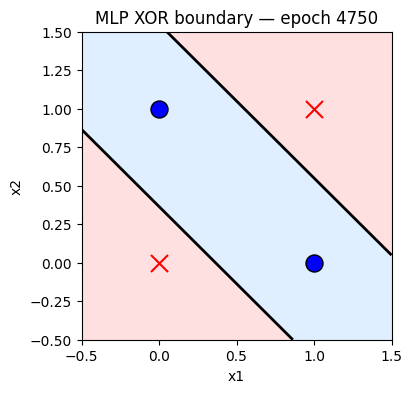


Final predictions:
input [0. 0.] -> pred 0, target 0.0
input [0. 1.] -> pred 1, target 1.0
input [1. 0.] -> pred 1, target 1.0
input [1. 1.] -> pred 0, target 0.0


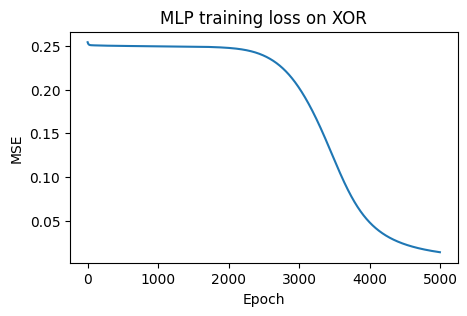

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class MLP:
    def __init__(self, lr=0.5):
        self.lr = lr
        self.W1 = np.random.uniform(-1, 1, (2, 2))
        self.b1 = np.random.uniform(-1, 1, (2,))
        self.W2 = np.random.uniform(-1, 1, (2, 1))
        self.b2 = np.random.uniform(-1, 1, (1,))
        self.loss_history = []
        self.snapshots = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_deriv(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        d_a2 = (self.a2 - y) * self.sigmoid_deriv(self.a2)
        d_W2 = self.a1.T @ d_a2 / m
        d_b2 = np.sum(d_a2, axis=0) / m
        d_a1 = (d_a2 @ self.W2.T) * self.sigmoid_deriv(self.a1)
        d_W1 = X.T @ d_a1 / m
        d_b1 = np.sum(d_a1, axis=0) / m
        self.W2 -= self.lr * d_W2
        self.b2 -= self.lr * d_b2
        self.W1 -= self.lr * d_W1
        self.b1 -= self.lr * d_b1

    def train(self, X, y, epochs=5000, snapshot_every=250):
        for epoch in range(epochs):
            out = self.forward(X)
            loss = np.mean((out.flatten() - y) ** 2)
            self.loss_history.append(loss)
            self.backward(X, y)
            if epoch % snapshot_every == 0:
                self.snapshots.append((epoch, self.W1.copy(), self.b1.copy(),
                                        self.W2.copy(), self.b2.copy()))
                print(f"Epoch {epoch}, loss {loss:.4f}")

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).flatten()


X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0], dtype=float)

mlp = MLP(lr=0.5)
mlp.train(X_xor, y_xor, epochs=5000, snapshot_every=250)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for epoch, W1, b1, W2, b2 in mlp.snapshots:
    z1 = grid @ W1 + b1
    a1 = 1 / (1 + np.exp(-z1))
    z2 = a1 @ W2 + b2
    preds = (1 / (1 + np.exp(-z2))).reshape(xx.shape)

    plt.figure(figsize=(4, 4))
    plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], colors=['#ffcccc', '#cce5ff'], alpha=0.6)
    plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=2)
    for xi, target in zip(X_xor, y_xor):
        color = 'blue' if target == 1 else 'red'
        marker = 'o' if target == 1 else 'x'
        plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150, edgecolors='k')
    plt.title(f"MLP XOR boundary — epoch {epoch}")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

print("\nFinal predictions:")
for xi, target in zip(X_xor, y_xor):
    pred = mlp.predict(xi.reshape(1, -1))[0]
    print(f"input {xi} -> pred {pred}, target {target}")

plt.figure(figsize=(5,3))
plt.plot(mlp.loss_history)
plt.title("MLP training loss on XOR")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.show()